In [1]:
!pip install -q datasets transformers tokenizers
print("Done")

Done


In [2]:
import math, time, os, json
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import GPT2TokenizerFast
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
CFG = {
    # Data
    "train_seq_len"  : 512,    # context length during training
    "batch_size"     : 16,     # reduce to 8 if OOM
    "num_workers"    : 2,

    # Architecture
    "vocab_size"     : 50257,
    "d_model"        : 256,
    "n_heads"        : 8,
    "n_layers"       : 4,
    "d_ff"           : 1024,
    "dropout"        : 0.1,

    # Training
    "epochs"         : 5,      # short run — enough to see extrapolation differences
    "lr"             : 3e-4,
    "warmup_steps"   : 500,
    "grad_clip"      : 1.0,
    "weight_decay"   : 0.01,

    # Logging
    "log_every"      : 200,
    "eval_every"     : 500,
    "save_dir"       : "./checkpoints_p3",

    # PE-specific
    "rope_base"      : 10000,  # RoPE base frequency (θ = base^(-2k/d))
    "alibi_max_bias" : 8.0,    # ALiBi maximum bias value (controls local-ness)
    "relpe_max_dist" : 128,    # Relative PE: max relative distance tracked

    # Extrapolation
    "eval_seq_lens"  : [512, 1024, 2048],
}

print("Config:")
for k,v in CFG.items(): print(f"  {k:<20} = {v}")

Config:
  train_seq_len        = 512
  batch_size           = 16
  num_workers          = 2
  vocab_size           = 50257
  d_model              = 256
  n_heads              = 8
  n_layers             = 4
  d_ff                 = 1024
  dropout              = 0.1
  epochs               = 5
  lr                   = 0.0003
  warmup_steps         = 500
  grad_clip            = 1.0
  weight_decay         = 0.01
  log_every            = 200
  eval_every           = 500
  save_dir             = ./checkpoints_p3
  rope_base            = 10000
  alibi_max_bias       = 8.0
  relpe_max_dist       = 128
  eval_seq_lens        = [512, 1024, 2048]


In [4]:
print("Loading WikiText-2 …")
try:
    raw = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1"
    )
except:
    raw = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1"
    )
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

class WikiTextDataset(Dataset):
    """Fixed-length windows from WikiText-2. seq_len is configurable."""

    def __init__(self, hf_split, tokenizer, seq_len: int, split_name=""):
        self.seq_len = seq_len
        texts = [s["text"] for s in hf_split if s["text"].strip()]
        full  = f" {tokenizer.eos_token} ".join(texts)
        ids   = tokenizer(full, return_tensors="pt",
                          truncation=False, add_special_tokens=False)["input_ids"].squeeze(0)
        n = (len(ids) - 1) // seq_len
        self.data = ids[: n * seq_len + 1]
        if split_name:
            print(f"  {split_name} (seq_len={seq_len}): {n:,} windows")

    def __len__(self): return (len(self.data) - 1) // self.seq_len
    def __getitem__(self, i):
        s = i * self.seq_len
        return self.data[s:s+self.seq_len], self.data[s+1:s+self.seq_len+1]

kw = dict(num_workers=CFG["num_workers"], pin_memory=True)
T_train = CFG["train_seq_len"]

# ── Training loaders (fixed at 512) ──────────────────────────────────────────
print("Building training datasets …")
train_ds     = WikiTextDataset(raw["train"],      tokenizer, T_train, "train")
valid_ds_512 = WikiTextDataset(raw["validation"], tokenizer, T_train, "valid-512")

train_loader     = DataLoader(train_ds,     CFG["batch_size"],   shuffle=True,  **kw)
valid_loader_512 = DataLoader(valid_ds_512, CFG["batch_size"]*2, shuffle=False, **kw)

# ── Extrapolation loaders ─────────────────────────────────────────────────────
print("\nBuilding extrapolation datasets …")
extrap_loaders = {}
for T_eval in CFG["eval_seq_lens"]:
    ds = WikiTextDataset(raw["validation"], tokenizer, T_eval, f"valid-{T_eval}")
    extrap_loaders[T_eval] = DataLoader(ds, max(1, CFG["batch_size"]*512//T_eval),
                                        shuffle=False, **kw)

print(f"\nTrain batches : {len(train_loader):,}")
print(f"Valid loaders : {list(extrap_loaders.keys())}")

Loading WikiText-2 …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Building training datasets …


Token indices sequence length is longer than the specified maximum sequence length for this model (2463182 > 1024). Running this sequence through the model will result in indexing errors


  train (seq_len=512): 4,810 windows
  valid-512 (seq_len=512): 497 windows

Building extrapolation datasets …
  valid-512 (seq_len=512): 497 windows
  valid-1024 (seq_len=1024): 248 windows
  valid-2048 (seq_len=2048): 124 windows

Train batches : 301
Valid loaders : [512, 1024, 2048]


In [5]:
class RotaryEmbedding(nn.Module):
    """
    Rotary Position Embedding (RoPE).

    Precomputes cos/sin tables for positions 0..max_seq_len.
    Applied to Q and K inside the attention module.

    The cos/sin values are cached and extended if a longer sequence appears
    (useful for the extrapolation experiments).

    Args:
        d_head   : dimension of each attention head
        base     : frequency base (default 10000, from RoFormer paper)
        max_len  : maximum sequence length to precompute (extended lazily)
    """

    def __init__(self, d_head: int, base: int = 10000, max_len: int = 2048):
        super().__init__()
        self.d_head  = d_head
        self.base    = base
        self.max_len = max_len
        # Precompute and cache — registered as buffer so they move to GPU
        self._build_cache(max_len)

    def _build_cache(self, seq_len: int):
        """Build and cache cos/sin tables up to seq_len."""
        # Frequencies: theta_k = base^(-2k/d_head)  for k=0,1,...,d_head/2-1
        k      = torch.arange(0, self.d_head, 2, dtype=torch.float32)  # (d//2,)
        theta  = 1.0 / (self.base ** (k / self.d_head))                # (d//2,)
        # Positions: 0, 1, 2, ..., seq_len-1
        pos    = torch.arange(seq_len, dtype=torch.float32)             # (T,)
        # Outer product: freqs[t,k] = t * theta[k], shape (T, d//2)
        freqs  = torch.outer(pos, theta)                                # (T, d//2)
        # Duplicate: cos(theta0), cos(theta0), cos(theta1), cos(theta1), ...
        # This matches the interleaved (x0,-x1,x0,x1) rotation convention
        freqs  = torch.cat([freqs, freqs], dim=-1)                      # (T, d_head)
        self.register_buffer("cos_cache", freqs.cos())
        self.register_buffer("sin_cache", freqs.sin())
        self.max_len = seq_len

    def _maybe_extend(self, T: int):
        """Extend cache if sequence is longer than cached length."""
        if T > self.max_len:
            self._build_cache(T * 2)    # double for headroom

    @staticmethod
    def _rotate_half(x: torch.Tensor) -> torch.Tensor:
        """
        Rotate the second half of the last dimension:
        [x0, x1, x2, x3] -> [-x2, -x3, x0, x1]

        Combined with cos/sin: achieves the 2D rotation in each subspace.
        """
        d = x.shape[-1] // 2
        x1, x2 = x[..., :d], x[..., d:]
        return torch.cat([-x2, x1], dim=-1)

    def rotate(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply rotary embedding to x.

        Args:
            x : (B, n_heads, T, d_head)
        Returns:
            x_rotated : (B, n_heads, T, d_head)
        """
        T = x.shape[2]
        self._maybe_extend(T)

        # Slice cos/sin to current sequence length: (T, d_head)
        cos = self.cos_cache[:T].unsqueeze(0).unsqueeze(0)  # (1, 1, T, d_head)
        sin = self.sin_cache[:T].unsqueeze(0).unsqueeze(0)  # (1, 1, T, d_head)

        # Apply rotation: x*cos + rotate_half(x)*sin
        return x * cos + self._rotate_half(x) * sin

    def forward(self, x):
        """Convenience alias for rotate()."""
        return self.rotate(x)


# ── RoPE Attention Module ─────────────────────────────────────────────────────
class RoPEAttention(nn.Module):
    """
    Multi-head self-attention with Rotary Position Embeddings.

    RoPE is applied to Q and K (NOT V) before computing attention scores.
    No positional information is added to the input embeddings.

    The model embedding layer should use nn.Embedding WITHOUT adding position
    embeddings when this attention is used.
    """

    def __init__(self, d_model, n_heads, rope_base=10000, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_head   = d_model // n_heads
        self.scale    = self.d_head ** -0.5

        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        # RoPE module — shared across all heads, applied per-head
        self.rope = RotaryEmbedding(self.d_head, base=rope_base, max_len=4096)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)  # each (B, H, T, d_head)

        # ── Apply RoPE to Q and K ─────────────────────────────────────────────
        # V is intentionally NOT rotated — it carries content, not position
        q = self.rope.rotate(q)
        k = self.rope.rotate(k)

        # Standard scaled dot-product attention
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale
        mask   = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        w      = self.attn_drop(F.softmax(scores, dim=-1))
        out    = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w


# Quick test
_attn = RoPEAttention(256, 8)
_x    = torch.randn(2, 32, 256)
_out, _w = _attn(_x)
print(f"RoPEAttention  in: {_x.shape}  →  out: {_out.shape}  weights: {_w.shape}")

RoPEAttention  in: torch.Size([2, 32, 256])  →  out: torch.Size([2, 32, 256])  weights: torch.Size([2, 8, 32, 32])


ALiBiAttention in: torch.Size([2, 32, 256])  →  out: torch.Size([2, 32, 256])  weights: torch.Size([2, 8, 32, 32])


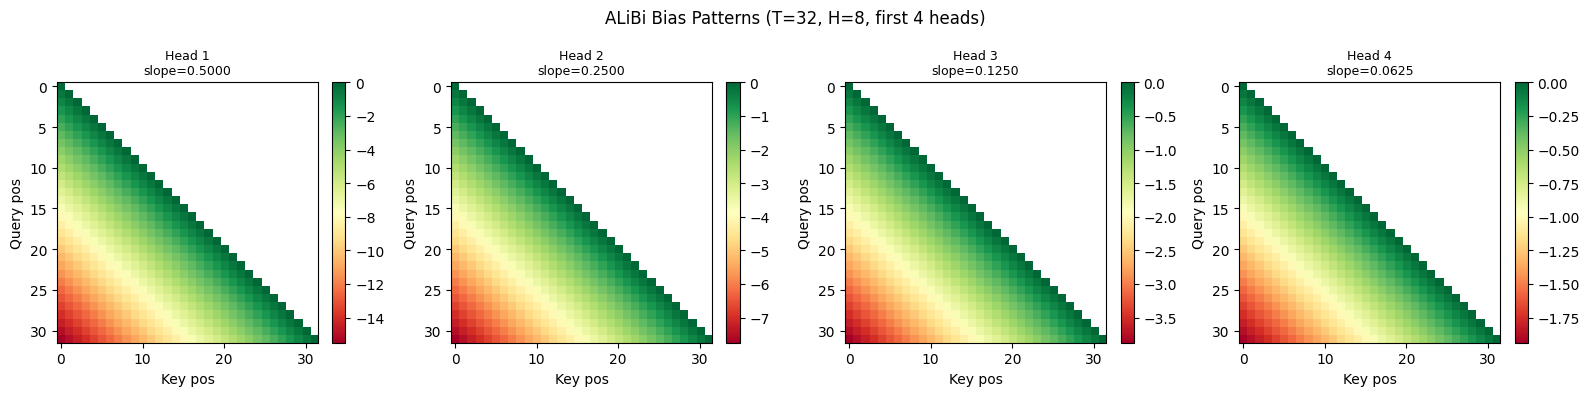

Saved → alibi_bias_pattern.png


In [6]:
class ALiBiAttention(nn.Module):
    """
    Attention with Linear Biases (ALiBi).

    Adds a fixed, non-learned linear distance penalty to attention scores.
    No positional information is added to the input embeddings.

    Score(i, j) = QK^T/sqrt(d) - m_h * (i - j)

    where m_h = 2^(-8h/H) is a head-specific slope.

    Reference: Press et al., 2021 — "Train Short, Test Long: Attention with
               Linear Biases Enables Input Length Extrapolation"

    Args:
        max_seq_len : maximum sequence length to pre-allocate the bias table
                      (extended lazily if exceeded)
    """

    def __init__(self, d_model, n_heads, max_seq_len=2048, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model    = d_model
        self.n_heads    = n_heads
        self.d_head     = d_model // n_heads
        self.scale      = self.d_head ** -0.5
        self.max_seq_len = max_seq_len

        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        # Pre-compute ALiBi slopes for each head
        # m_h = 2^(-8h/H)  for h = 1..H
        slopes = torch.tensor(
            [2 ** (-8 * h / n_heads) for h in range(1, n_heads + 1)],
            dtype=torch.float32
        )   # (H,)
        self.register_buffer("slopes", slopes)

        # Pre-compute the relative distance table
        self._build_bias(max_seq_len)

    def _build_bias(self, max_len: int):
        """
        Pre-compute the ALiBi bias table for up to max_len positions.

        bias[h, i, j] = -slope[h] * max(0, i - j)   (causal: j <= i only)

        Shape: (1, H, max_len, max_len) — broadcastable over batch.
        """
        # Relative distances: dist[i,j] = max(0, i-j)
        pos  = torch.arange(max_len)
        dist = torch.clamp(pos.unsqueeze(1) - pos.unsqueeze(0), min=0)  # (T,T), >= 0
        # bias[h,i,j] = -slopes[h] * dist[i,j]
        # slopes: (H,), dist: (T,T) → outer product → (H,T,T)
        bias = -self.slopes.unsqueeze(-1).unsqueeze(-1) * dist.float()  # (H,T,T)
        # (H,T,T) → (1,H,T,T) for batch broadcasting
        self.register_buffer("alibi_bias", bias.unsqueeze(0))
        self.max_seq_len = max_len

    def _maybe_extend(self, T: int):
        if T > self.max_seq_len:
            self._build_bias(T * 2)

    def forward(self, x):
        B, T, C = x.shape
        self._maybe_extend(T)

        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)

        # Standard dot-product scores
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale   # (B,H,T,T)

        # ── Add ALiBi bias ────────────────────────────────────────────────────
        # Slice to current sequence length: (1, H, T, T)
        bias   = self.alibi_bias[:, :, :T, :T]
        scores = scores + bias

        # ── Causal mask (future positions → -inf) ─────────────────────────────
        # Note: ALiBi does NOT use -inf for past positions — just the linear penalty.
        # We still need the causal mask for future positions.
        mask   = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))

        w   = self.attn_drop(F.softmax(scores, dim=-1))
        out = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w


# Quick test
_attn = ALiBiAttention(256, 8)
_out, _w = _attn(_x)
print(f"ALiBiAttention in: {_x.shape}  →  out: {_out.shape}  weights: {_w.shape}")

# Visualise the ALiBi bias pattern
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
T_vis = 32
_attn_vis = ALiBiAttention(256, 8, max_seq_len=T_vis)
for hi, ax in enumerate(axes):
    # bias for head hi: (T,T)
    b = _attn_vis.alibi_bias[0, hi, :T_vis, :T_vis].cpu().numpy()
    # mask future positions for visualisation
    causal = np.triu(np.ones((T_vis, T_vis)), k=1).astype(bool)
    b_masked = np.where(causal, np.nan, b)
    im = ax.imshow(b_masked, cmap="RdYlGn", aspect="auto")
    slope = 2**(-8*(hi+1)/8)
    ax.set_title(f"Head {hi+1}\nslope={slope:.4f}", fontsize=9)
    ax.set_xlabel("Key pos"); ax.set_ylabel("Query pos")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("ALiBi Bias Patterns (T=32, H=8, first 4 heads)", fontsize=12)
plt.tight_layout(); plt.savefig("alibi_bias_pattern.png", dpi=120); plt.show()
print("Saved → alibi_bias_pattern.png")

In [7]:
class RelativePositionEncoding(nn.Module):
    """
    Relative position bias (Shaw et al., 2018).

    Learns a bias table indexed by clipped relative offset (i - j).
    Offsets are clipped to [-max_distance, 0] (causal: only past positions).

    This is added to attention logits as a scalar bias per (query, key) pair.

    Args:
        n_heads      : number of attention heads
        max_distance : maximum tracked distance (beyond this, shared embedding)
    """

    def __init__(self, n_heads: int, max_distance: int = 128):
        super().__init__()
        self.n_heads      = n_heads
        self.max_distance = max_distance
        # Bias table: (max_distance + 1) offsets × n_heads
        # Offset 0 → self, offset max_distance → very far past
        # Shape: (n_heads, max_distance + 1)
        self.bias_table = nn.Embedding(max_distance + 1, n_heads)
        nn.init.zeros_(self.bias_table.weight)   # initialise to zero (no bias at start)

    def forward(self, T: int, device: torch.device) -> torch.Tensor:
        """
        Compute relative position bias for a sequence of length T.

        Returns:
            bias : (1, n_heads, T, T) — broadcastable over batch
        """
        # Compute relative offsets: offset[i,j] = i - j
        # For causal attention, only j <= i matters, so offsets >= 0
        positions = torch.arange(T, device=device)
        offsets   = positions.unsqueeze(1) - positions.unsqueeze(0)  # (T,T) can be negative

        # Clip to [0, max_distance]: clamp to positives (i >= j for causal)
        # Negative offsets (future tokens) will be masked, so their bias value
        # doesn't matter — we set them to 0 (index 0) for convenience
        offsets_clipped = torch.clamp(offsets, min=0, max=self.max_distance)  # (T,T)

        # Look up bias for each (query, key) offset
        # bias_table: (max_distance+1, n_heads)
        # offsets_clipped: (T, T) of indices
        bias = self.bias_table(offsets_clipped)   # (T, T, n_heads)

        # Rearrange to (1, n_heads, T, T)
        bias = bias.permute(2, 0, 1).unsqueeze(0)  # (1, n_heads, T, T)
        return bias


class RelativePEAttention(nn.Module):
    """
    Multi-head self-attention with learned relative position biases.

    score(i,j) = QK^T/sqrt(d) + RelBias(i-j)

    Relative biases are learned scalars (one per head per offset bucket).
    Offsets beyond max_distance share a single embedding.
    """

    def __init__(self, d_model, n_heads, max_distance=128, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_head   = d_model // n_heads
        self.scale    = self.d_head ** -0.5

        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        # Relative position bias module
        self.rel_pe = RelativePositionEncoding(n_heads, max_distance)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)

        # Dot-product scores
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale  # (B,H,T,T)

        # ── Add relative position bias ────────────────────────────────────────
        rel_bias = self.rel_pe(T, x.device)   # (1, H, T, T)
        scores   = scores + rel_bias

        # Causal mask
        mask   = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))

        w   = self.attn_drop(F.softmax(scores, dim=-1))
        out = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w


# Quick test
_attn = RelativePEAttention(256, 8, max_distance=128)
_out, _w = _attn(_x)
print(f"RelativePEAttn in: {_x.shape}  →  out: {_out.shape}  weights: {_w.shape}")

RelativePEAttn in: torch.Size([2, 32, 256])  →  out: torch.Size([2, 32, 256])  weights: torch.Size([2, 8, 32, 32])


In [8]:
class LearnedPEAttention(nn.Module):
    """
    Standard multi-head self-attention WITHOUT any positional encoding.
    Positional information is injected via a learned pos embedding in the
    input layer (the LM's tok_emb + pos_emb sum, same as Phase 1).

    This is the baseline — included here so all variants use the same
    TransformerBlock structure.
    """

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_head   = d_model // n_heads
        self.scale    = self.d_head ** -0.5
        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale
        mask   = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        w      = self.attn_drop(F.softmax(scores, dim=-1))
        out    = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w

print("All four attention modules defined.")
print("  LearnedPEAttention  (PE in embedding layer)")
print("  RoPEAttention       (PE via Q,K rotation)")
print("  ALiBiAttention      (PE via attention score bias)")
print("  RelativePEAttention (PE via learned relative bias)")

All four attention modules defined.
  LearnedPEAttention  (PE in embedding layer)
  RoPEAttention       (PE via Q,K rotation)
  ALiBiAttention      (PE via attention score bias)
  RelativePEAttention (PE via learned relative bias)


In [9]:
# ── Shared transformer components ────────────────────────────────────────────

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, attn_module, d_model, d_ff, dropout):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = attn_module
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        a, w = self.attn(self.ln1(x));  x = x + a
        return x + self.ff(self.ln2(x)), w


class LanguageModel(nn.Module):
    """
    Decoder-only LM supporting pluggable positional encoding.

    Args:
        cfg          : config dict
        attn_modules : list of attention modules (one per layer)
        use_pos_emb  : if True, add learned pos embedding in input layer
                       (set False for RoPE and ALiBi — they handle position internally)
        max_pos_emb  : max sequence length for the pos embedding table
    """

    def __init__(self, cfg, attn_modules, use_pos_emb=True, max_pos_emb=512):
        super().__init__()
        D, V = cfg["d_model"], cfg["vocab_size"]
        self.use_pos_emb = use_pos_emb

        self.tok_emb = nn.Embedding(V, D)
        # Positional embedding: only used when use_pos_emb=True
        # Size fixed at max_pos_emb — will FAIL for longer sequences (by design,
        # to demonstrate the extrapolation failure)
        if use_pos_emb:
            self.pos_emb = nn.Embedding(2048, D)

        self.drop   = nn.Dropout(cfg["dropout"])
        self.blocks = nn.ModuleList([
            TransformerBlock(attn, D, cfg["d_ff"], cfg["dropout"])
            for attn in attn_modules
        ])
        self.ln_f    = nn.LayerNorm(D)
        self.lm_head = nn.Linear(D, V, bias=False)
        self.lm_head.weight = self.tok_emb.weight   # weight tying
        self.apply(self._init_weights)
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Parameters: {n:,} ({n/1e6:.2f}M)  |  use_pos_emb={use_pos_emb}")

    def _init_weights(self, m):
        if isinstance(m, nn.Linear): nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.LayerNorm): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, idx):
        B, T = idx.shape
        x = self.tok_emb(idx)
        if self.use_pos_emb:
            # This will raise IndexError for T > max_pos_emb — intentional
            # to demonstrate that learned PE cannot extrapolate
            pos = torch.arange(T, device=idx.device)
            x   = x + self.pos_emb(pos)
        x = self.drop(x)
        attn_list = []
        for blk in self.blocks:
            x, w = blk(x); attn_list.append(w)
        return self.ln_f(x) @ self.lm_head.weight.T, attn_list


# ── PE registry ──────────────────────────────────────────────────────────────
def build_pe_model(cfg, pe_type: str) -> LanguageModel:
    """
    Build a language model with the specified positional encoding.

    pe_type options: 'learned', 'rope', 'alibi', 'relative'
    """
    D, H, L = cfg["d_model"], cfg["n_heads"], cfg["n_layers"]
    dr       = cfg["dropout"]
    T_train  = cfg["train_seq_len"]

    PE_CONFIG = {
        "learned" : {
            "make_attn"   : lambda: LearnedPEAttention(D, H, dr),
            "use_pos_emb" : True,
            "max_pos_emb" : T_train,   # learned table fixed at training length
        },
        "rope" : {
            "make_attn"   : lambda: RoPEAttention(D, H, cfg["rope_base"], dr),
            "use_pos_emb" : False,     # RoPE handles position inside attention
        },
        "alibi" : {
            "make_attn"   : lambda: ALiBiAttention(D, H, max_seq_len=4096, dropout=dr),
            "use_pos_emb" : False,     # ALiBi handles position inside attention
        },
        "relative" : {
            "make_attn"   : lambda: RelativePEAttention(D, H, cfg["relpe_max_dist"], dr),
            "use_pos_emb" : False,      # Relative PE is additive to learned pos emb
            "max_pos_emb" : T_train,
        },
    }

    if pe_type not in PE_CONFIG: raise ValueError(f"Unknown PE: {pe_type}")
    pc = PE_CONFIG[pe_type]

    print(f"\nBuilding model  pe='{pe_type}' …")
    attn_modules = [pc["make_attn"]() for _ in range(L)]
    return LanguageModel(
        cfg, attn_modules,
        use_pos_emb = pc.get("use_pos_emb", False),
        max_pos_emb = pc.get("max_pos_emb", T_train),
    ).to(DEVICE)


# Build all variants and do a quick forward pass
for pe in ["learned", "rope", "alibi", "relative"]:
    m  = build_pe_model(CFG, pe)
    _x = torch.randint(0, CFG["vocab_size"], (1, 32), device=DEVICE)
    _o, _ = m(_x)
    print(f"  ✔  {pe:10s}  output: {_o.shape}")
    del m, _x, _o


Building model  pe='learned' …
  Parameters: 16,545,536 (16.55M)  |  use_pos_emb=True
  ✔  learned     output: torch.Size([1, 32, 50257])

Building model  pe='rope' …
  Parameters: 16,021,248 (16.02M)  |  use_pos_emb=False
  ✔  rope        output: torch.Size([1, 32, 50257])

Building model  pe='alibi' …
  Parameters: 16,021,248 (16.02M)  |  use_pos_emb=False
  ✔  alibi       output: torch.Size([1, 32, 50257])

Building model  pe='relative' …
  Parameters: 16,025,376 (16.03M)  |  use_pos_emb=False
  ✔  relative    output: torch.Size([1, 32, 50257])


In [10]:
def compute_loss(logits, targets):
    B, T, V = logits.shape
    return F.cross_entropy(
    logits.reshape(B*T, V),
    targets.reshape(B*T)
)
def get_lr(step, total_steps, cfg):
    w, hi, lo = cfg["warmup_steps"], cfg["lr"], cfg["lr"]*0.1
    if step < w: return hi*(step+1)/w
    prog = min((step-w)/max(1,total_steps-w), 1.0)
    return lo + 0.5*(hi-lo)*(1+math.cos(math.pi*prog))

@torch.no_grad()
def evaluate_at_len(model, loader, max_batches=None):
    """Evaluate model on a loader, optionally capped at max_batches."""
    model.eval(); tot=n=0
    for i, (x,y) in enumerate(loader):
        if max_batches and i >= max_batches: break
        x,y = x.to(DEVICE), y.to(DEVICE)
        try:
            logits, _ = model(x)
            tot += compute_loss(logits, y).item(); n += 1
        except (IndexError, RuntimeError):
            # IndexError: learned PE fails on T > max_pos_emb
            # RuntimeError: other shape issues
            return {"loss": float("inf"), "ppl": float("inf"),
                    "failed": True, "n_batches": i}
    model.train()
    if n == 0: return {"loss": float("inf"), "ppl": float("inf"), "failed": True}
    avg = tot / n
    return {"loss": avg, "ppl": math.exp(min(avg, 20)), "failed": False, "n_batches": n}

def make_optimiser(model, cfg):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad: continue
        (no_decay if p.dim()==1 or any(k in name for k in ("ln","bias","emb")) else decay).append(p)
    return torch.optim.AdamW(
        [{"params":decay,"weight_decay":cfg["weight_decay"]},
         {"params":no_decay,"weight_decay":0.0}],
        lr=cfg["lr"], betas=(0.9,0.95), eps=1e-8)

def train_pe_variant(model, cfg, pe_name):
    """Train a PE variant for cfg['epochs'] and return history."""
    os.makedirs(cfg["save_dir"], exist_ok=True)
    opt   = make_optimiser(model, cfg)
    total = cfg["epochs"] * len(train_loader)
    step  = 0
    history = {"tl":[],"ts":[],"vl":[],"vp":[],"vs":[]}
    model.train()

    print(f"\n{'='*55}")
    print(f"  Training PE variant: {pe_name}  ({cfg['epochs']} epochs)")
    print(f"{'='*55}")

    for ep in range(cfg["epochs"]):
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            for pg in opt.param_groups: pg["lr"] = get_lr(step, total, cfg)
            with torch.autocast(
              device_type="cuda",
              dtype=torch.float16,
              enabled=(DEVICE.type=="cuda")
            ):
              logits, _ = model(x)
              loss = compute_loss(logits, y)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step()
            lv = loss.item()
            history["tl"].append(lv); history["ts"].append(step)
            if step % cfg["log_every"] == 0:
                print(f"  [{pe_name}] Ep{ep+1} Step{step:5d} "
                      f"Loss{lv:.4f} PPL{math.exp(lv):.1f}")
            if step % cfg["eval_every"] == 0 and step > 0:
                vm = evaluate_at_len(model, valid_loader_512)
                history["vl"].append(vm["loss"]); history["vp"].append(vm["ppl"])
                history["vs"].append(step)
                print(f"  [{pe_name}] VALID Loss{vm['loss']:.4f} PPL{vm['ppl']:.2f}")
            step += 1
        ep_avg = sum(history["tl"][-len(train_loader):])/len(train_loader)
        print(f"  [{pe_name}] Epoch{ep+1} done | AvgPPL {math.exp(ep_avg):.2f}")

    final = evaluate_at_len(model, valid_loader_512)
    history["final_ppl"]  = final["ppl"]
    history["final_loss"] = final["loss"]
    torch.save({"model":model.state_dict(),"history":history,"cfg":cfg},
               f"{cfg['save_dir']}/{pe_name}_final.pt")
    print(f"  [{pe_name}] FINAL PPL={final['ppl']:.2f}")
    return history

print("Training utilities ready.")

Training utilities ready.


In [11]:
all_models    = {}
all_histories = {}

for pe_name in ["learned", "rope", "alibi", "relative"]:
    # Fresh model
    model = build_pe_model(CFG, pe_name)

    # Train
    hist = train_pe_variant(model, CFG, pe_name)
    all_histories[pe_name] = hist
    all_models[pe_name]    = model

    # Optionally free GPU between variants:
    # del model; torch.cuda.empty_cache()

print("\nAll PE variants trained.")


Building model  pe='learned' …
  Parameters: 16,545,536 (16.55M)  |  use_pos_emb=True

  Training PE variant: learned  (5 epochs)
  [learned] Ep1 Step    0 Loss10.8921 PPL53748.3
  [learned] Ep1 Step  200 Loss8.6278 PPL5584.9
  [learned] Epoch1 done | AvgPPL 9891.97
  [learned] Ep2 Step  400 Loss6.9846 PPL1079.8
  [learned] VALID Loss7.1021 PPL1214.47
  [learned] Ep2 Step  600 Loss7.2961 PPL1474.5
  [learned] Epoch2 done | AvgPPL 1213.24
  [learned] Ep3 Step  800 Loss8.0064 PPL3000.0
  [learned] Epoch3 done | AvgPPL 2207.38
  [learned] Ep4 Step 1000 Loss8.2418 PPL3796.2
  [learned] VALID Loss8.3899 PPL4402.55
  [learned] Ep4 Step 1200 Loss8.3775 PPL4348.0
  [learned] Epoch4 done | AvgPPL 4201.34
  [learned] Ep5 Step 1400 Loss8.5711 PPL5277.1
  [learned] VALID Loss8.9565 PPL7757.81
  [learned] Epoch5 done | AvgPPL 5943.23
  [learned] FINAL PPL=7692.76

Building model  pe='rope' …
  Parameters: 16,021,248 (16.02M)  |  use_pos_emb=False

  Training PE variant: rope  (5 epochs)
  [rope] E

In [12]:
print("Running extrapolation experiments …")
print("(Each model evaluated at T=512, 1024, 2048)\n")

extrap_results = {}   # extrap_results[pe_name][T_eval] = {"ppl": ..., "failed": ...}

for pe_name, model in all_models.items():
    extrap_results[pe_name] = {}
    model.eval()

    for T_eval, loader in extrap_loaders.items():
        print(f"  [{pe_name}]  T={T_eval} … ", end="", flush=True)

        # Cap at 50 batches for speed (enough for stable PPL estimate)
        metrics = evaluate_at_len(model, loader, max_batches=50)

        extrap_results[pe_name][T_eval] = metrics

        if metrics["failed"]:
            print(f"FAILED (inference error at T={T_eval})")
        else:
            print(f"PPL={metrics['ppl']:.2f}")

    model.train()

print("\nExtrapolation complete.")

Running extrapolation experiments …
(Each model evaluated at T=512, 1024, 2048)

  [learned]  T=512 … PPL=7574.03
  [learned]  T=1024 … PPL=7836.60
  [learned]  T=2048 … PPL=7923.52
  [rope]  T=512 … PPL=4849.58
  [rope]  T=1024 … PPL=4948.95
  [rope]  T=2048 … PPL=5275.49
  [alibi]  T=512 … PPL=5017.15
  [alibi]  T=1024 … PPL=5026.06
  [alibi]  T=2048 … PPL=5021.96
  [relative]  T=512 … PPL=6413.83
  [relative]  T=1024 … PPL=6476.03
  [relative]  T=2048 … PPL=6523.78

Extrapolation complete.


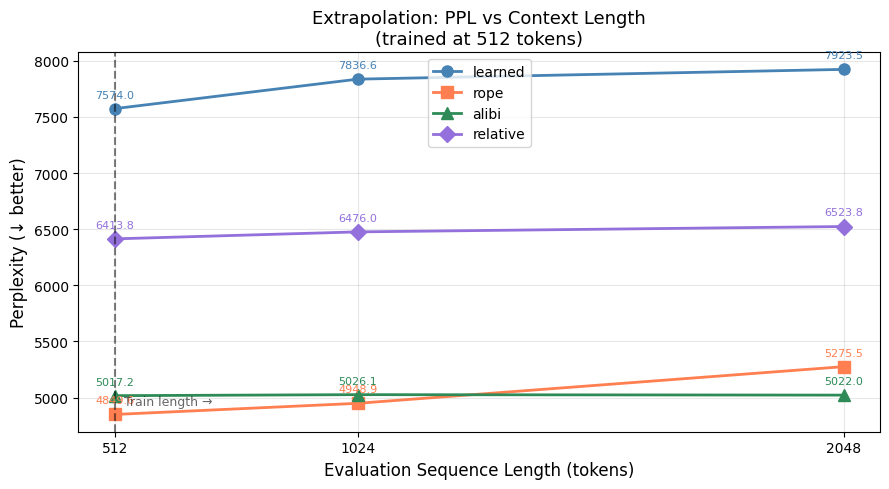

Saved → extrapolation_ppl.png


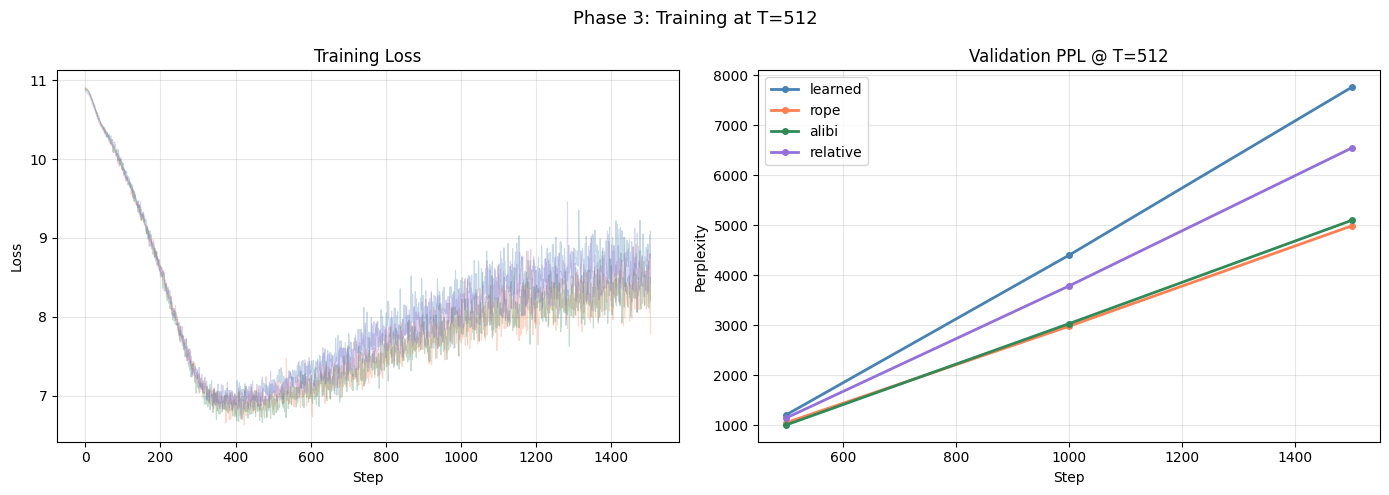

Saved → pe_training_curves.png

PHASE 3: EXTRAPOLATION RESULTS
(Trained at T=512, evaluated at T=512/1024/2048)
Encoding           PPL@512    PPL@1024    PPL@2048
------------------------------------------------------------------------
learned            7574.03     7836.60     7923.52
rope               4849.58     4948.95     5275.49
alibi              5017.15     5026.06     5021.96
relative           6413.83     6476.03     6523.78

Saved → phase3_summary.json


In [13]:
COLORS = {
    "learned"  : "steelblue",
    "rope"     : "coral",
    "alibi"    : "seagreen",
    "relative" : "mediumpurple",
}
MARKERS = {"learned":"o", "rope":"s", "alibi":"^", "relative":"D"}
PE_NAMES = list(all_models.keys())
T_EVALS  = CFG["eval_seq_lens"]

# ── Figure 1: Extrapolation PPL vs sequence length ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for pe_name in PE_NAMES:
    ppls = []
    Ts   = []
    for T_eval in T_EVALS:
        m = extrap_results[pe_name][T_eval]
        if not m["failed"]:
            ppls.append(m["ppl"]); Ts.append(T_eval)

    if ppls:
        ax.plot(Ts, ppls,
                marker=MARKERS[pe_name], color=COLORS[pe_name],
                lw=2, ms=8, label=pe_name)
        for T, ppl in zip(Ts, ppls):
            ax.annotate(f"{ppl:.1f}", (T, ppl),
                        textcoords="offset points", xytext=(0,8),
                        fontsize=8, ha="center", color=COLORS[pe_name])
    else:
        ax.scatter([], [], marker=MARKERS[pe_name],
                   color=COLORS[pe_name], label=f"{pe_name} (all failed)")

# Mark failed variants
for pe_name in PE_NAMES:
    for T_eval in T_EVALS:
        m = extrap_results[pe_name][T_eval]
        if m["failed"]:
            ax.axvline(T_eval, color="red", alpha=0.15, linestyle="--")
            ax.annotate(f"{pe_name}\nfailed", (T_eval, ax.get_ylim()[1]*0.95),
                        fontsize=7, ha="center", color="red", alpha=0.8)

ax.axvline(CFG["train_seq_len"], color="black", linestyle="--", alpha=0.5, lw=1.5)
ax.text(CFG["train_seq_len"]+20, ax.get_ylim()[0]*1.05,
        "Train length →", fontsize=9, alpha=0.6)
ax.set_xlabel("Evaluation Sequence Length (tokens)", fontsize=12)
ax.set_ylabel("Perplexity (↓ better)", fontsize=12)
ax.set_title("Extrapolation: PPL vs Context Length\n(trained at 512 tokens)", fontsize=13)
ax.set_xticks(T_EVALS); ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("extrapolation_ppl.png", dpi=150); plt.show()
print("Saved → extrapolation_ppl.png")

# ── Figure 2: Training curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for pe_name, hist in all_histories.items():
    ax.plot(hist["ts"], hist["tl"], alpha=0.3, color=COLORS[pe_name], lw=0.8)
ax.set(xlabel="Step", ylabel="Loss", title="Training Loss"); ax.grid(alpha=0.3)

ax = axes[1]
for pe_name, hist in all_histories.items():
    if hist["vs"]:
        ax.plot(hist["vs"], hist["vp"],
                "o-", color=COLORS[pe_name], lw=2, ms=4, label=pe_name)
ax.set(xlabel="Step", ylabel="Perplexity", title="Validation PPL @ T=512")
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Phase 3: Training at T=512", fontsize=13)
plt.tight_layout(); plt.savefig("pe_training_curves.png", dpi=150); plt.show()
print("Saved → pe_training_curves.png")

# ── Results table ─────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("PHASE 3: EXTRAPOLATION RESULTS")
print(f"(Trained at T={CFG['train_seq_len']}, evaluated at T=512/1024/2048)")
print("="*72)
header = f"{'Encoding':<14}" + "".join(f"{'PPL@'+str(T):>12}" for T in T_EVALS)
print(header); print("-"*72)
for pe_name in PE_NAMES:
    row = f"{pe_name:<14}"
    for T_eval in T_EVALS:
        m = extrap_results[pe_name][T_eval]
        if m["failed"]: row += f"{'FAILED':>12}"
        else:           row += f"{m['ppl']:>12.2f}"
    print(row)
print("="*72)

# Save
summary = {}
for pe_name in PE_NAMES:
    summary[pe_name] = {
        "final_train_ppl" : all_histories[pe_name]["final_ppl"],
        "extrapolation"   : {
            str(T): {"ppl": extrap_results[pe_name][T]["ppl"],
                     "failed": extrap_results[pe_name][T]["failed"]}
            for T in T_EVALS
        }
    }
with open("phase3_summary.json","w") as f: json.dump(summary, f, indent=2)
print("\nSaved → phase3_summary.json")

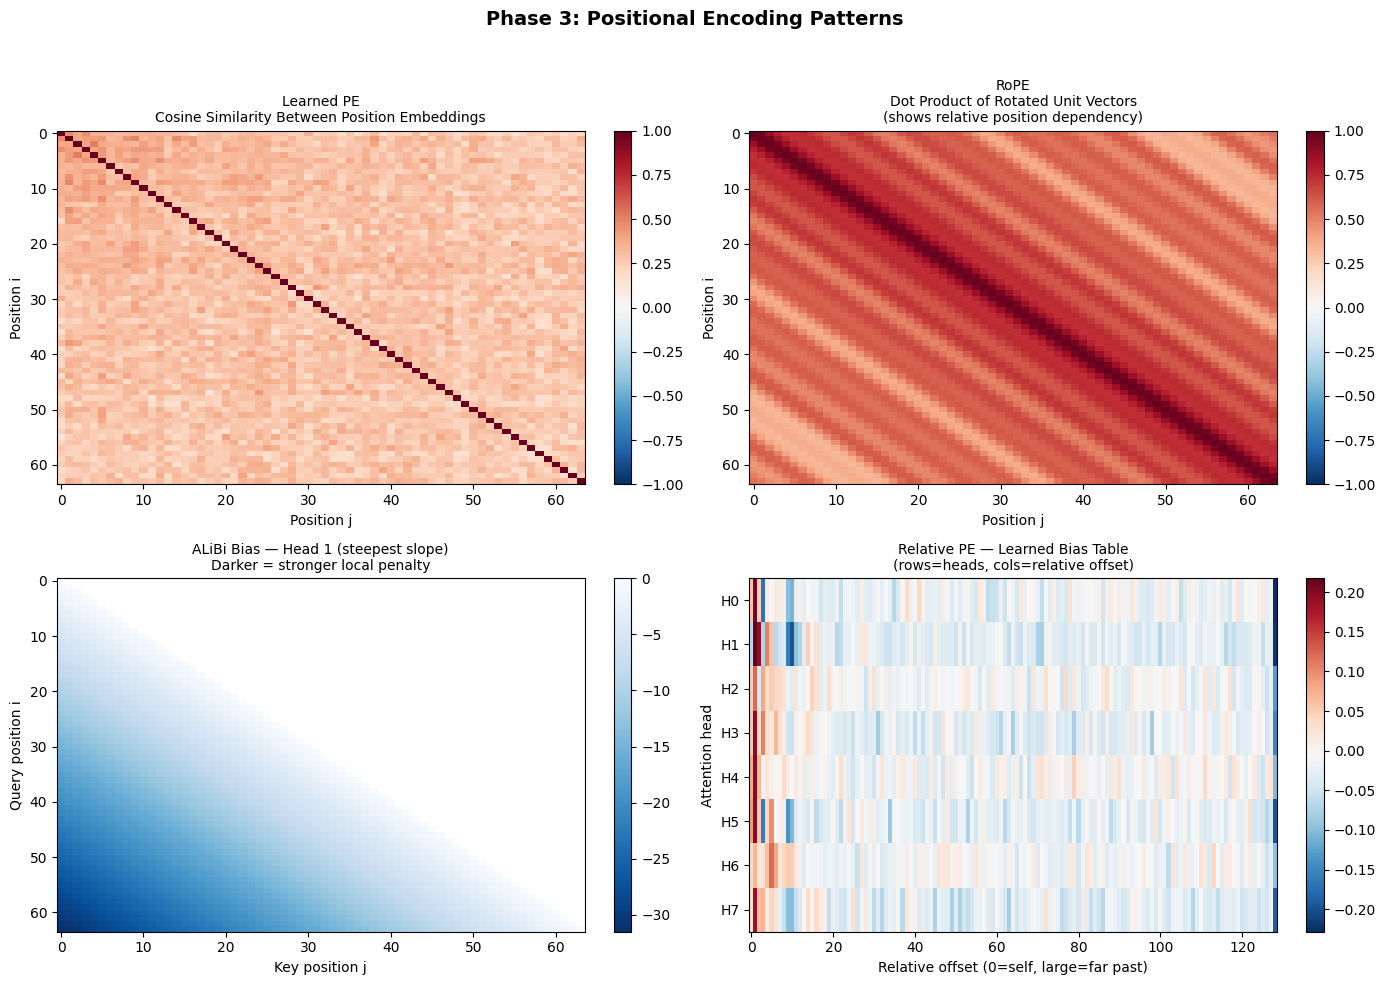

Saved → pe_patterns.png


In [14]:
# ── Figure 3: PE visualisations ──────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

T_VIS = 64   # short sequence for clear visualisation

# ── 1. Learned PE: show the positional embedding cosine similarity matrix ─────
ax = axes[0]
model_l = all_models["learned"]
if hasattr(model_l, "pos_emb"):
    pe_vecs = model_l.pos_emb.weight.detach().cpu()[:T_VIS]   # (T, D)
    pe_norm = F.normalize(pe_vecs, dim=-1)
    sim     = (pe_norm @ pe_norm.T).numpy()   # cosine similarity (T, T)
    im = ax.imshow(sim, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
    ax.set_title("Learned PE\nCosine Similarity Between Position Embeddings", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xlabel("Position j"); ax.set_ylabel("Position i")

# ── 2. RoPE: show the dot product of rotated unit vectors ────────────────────
ax = axes[1]
rope_module = RotaryEmbedding(32, base=10000, max_len=T_VIS)  # d_head=32
# Create unit query vectors
unit_q = torch.ones(1, 1, T_VIS, 32) / math.sqrt(32)
rotated = rope_module.rotate(unit_q)[0, 0]  # (T, d_head)
sim_rope = (rotated @ rotated.T).detach().cpu().numpy()
im = ax.imshow(sim_rope, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
ax.set_title("RoPE\nDot Product of Rotated Unit Vectors\n(shows relative position dependency)", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel("Position j"); ax.set_ylabel("Position i")

# ── 3. ALiBi: show bias for head 1 (steep) and head 8 (gentle) ───────────────
ax = axes[2]
model_a = all_models["alibi"]
# Get the ALiBi bias from the first block's attention module
alibi_attn = model_a.blocks[0].attn
bias_h0 = alibi_attn.alibi_bias[0, 0, :T_VIS, :T_VIS].cpu().numpy()  # head 0 (steepest)
bias_h7 = alibi_attn.alibi_bias[0, 7, :T_VIS, :T_VIS].cpu().numpy()  # head 7 (gentlest)
# Mask future positions (they'll be -inf in real attention)
causal_mask = np.triu(np.ones((T_VIS, T_VIS)), k=1).astype(bool)
bias_h0[causal_mask] = np.nan
bias_h7[causal_mask] = np.nan
# Show difference to illustrate both extremes
im = ax.imshow(bias_h0, cmap="Blues_r", aspect="auto")
ax.set_title("ALiBi Bias — Head 1 (steepest slope)\n"
                 "Darker = stronger local penalty", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel("Key position j"); ax.set_ylabel("Query position i")

# ── 4. Relative PE: show learned bias table ───────────────────────────────────
ax = axes[3]
model_r   = all_models["relative"]
relpe_mod = model_r.blocks[0].attn.rel_pe
bias_tbl  = relpe_mod.bias_table.weight.detach().cpu().numpy()  # (max_dist+1, H)
im = ax.imshow(bias_tbl.T, cmap="RdBu_r", aspect="auto")
ax.set_title("Relative PE — Learned Bias Table\n"
                 "(rows=heads, cols=relative offset)", fontsize=10)
ax.set_xlabel("Relative offset (0=self, large=far past)")
ax.set_ylabel("Attention head")
ax.set_yticks(range(CFG["n_heads"]))
ax.set_yticklabels([f"H{i}" for i in range(CFG["n_heads"])])
plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Phase 3: Positional Encoding Patterns", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("pe_patterns.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved → pe_patterns.png")

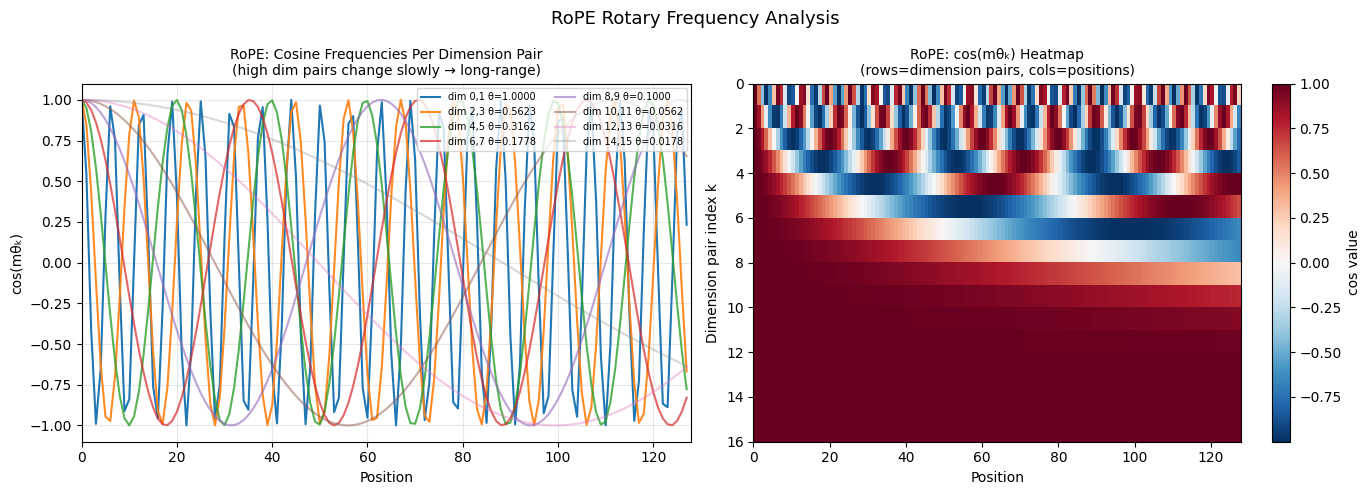

Saved → rope_frequencies.png


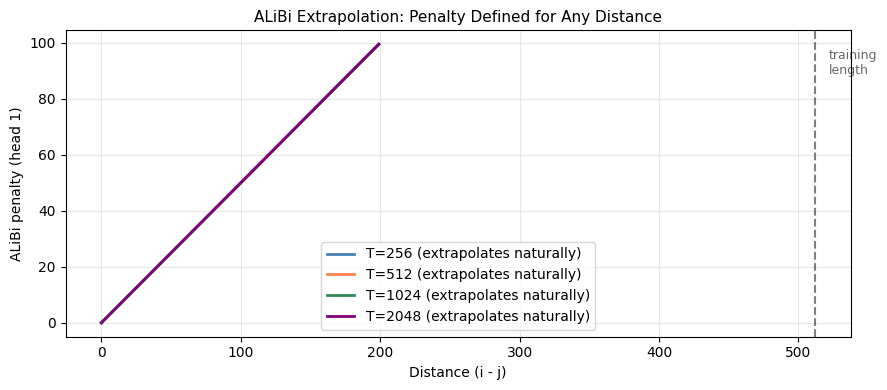

Saved → alibi_extrapolation.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: show the angle (frequency × position) for first 16 pairs
ax = axes[0]
d_head = CFG["d_model"] // CFG["n_heads"]   # 32
T_vis2 = 128
k_vals  = np.arange(0, d_head, 2)           # [0, 2, 4, ..., d_head-2]
thetas  = 1.0 / (10000 ** (k_vals / d_head))
pos_arr = np.arange(T_vis2)
angles  = np.outer(pos_arr, thetas)          # (T, d_head//2) — angle for each pos/dim

# Plot first 8 dimension-pairs
for ki in range(0, min(8, d_head//2)):
    alpha = 1.0 - 0.1 * ki
    ax.plot(pos_arr, np.cos(angles[:, ki]),
            alpha=alpha, lw=1.5,
            label=f"dim {ki*2},{ki*2+1} θ={thetas[ki]:.4f}")

ax.set_xlabel("Position"); ax.set_ylabel("cos(mθₖ)")
ax.set_title("RoPE: Cosine Frequencies Per Dimension Pair\n"
                 "(high dim pairs change slowly → long-range)", fontsize=10)
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.grid(alpha=0.3); ax.set_xlim(0, T_vis2)

# Right: heatmap of all cos values
ax = axes[1]
im = ax.imshow(np.cos(angles).T, aspect="auto", cmap="RdBu_r",
               extent=[0, T_vis2, d_head//2, 0])
ax.set_xlabel("Position"); ax.set_ylabel("Dimension pair index k")
ax.set_title("RoPE: cos(mθₖ) Heatmap\n"
                 "(rows=dimension pairs, cols=positions)", fontsize=10)
plt.colorbar(im, ax=ax, label="cos value")

plt.suptitle("RoPE Rotary Frequency Analysis", fontsize=13)
plt.tight_layout(); plt.savefig("rope_frequencies.png", dpi=150); plt.show()
print("Saved → rope_frequencies.png")

# Also: show how ALiBi attention patterns degrade gracefully
fig, ax = plt.subplots(figsize=(9, 4))
Ts_plot = [256, 512, 1024, 2048]
for color, T_plot in zip(["steelblue","coral","seagreen","purple"], Ts_plot):
    # ALiBi head 1 (steepest): penalty at each distance
    dist     = np.arange(T_plot)
    slope_h1 = 2**(-8*1/CFG["n_heads"])
    penalty  = slope_h1 * dist
    ax.plot(dist[:200], penalty[:200], color=color, lw=2,
            label=f"T={T_plot} (extrapolates naturally)")
ax.axvline(CFG["train_seq_len"], color="black", linestyle="--", alpha=0.5)
ax.text(CFG["train_seq_len"]+10, ax.get_ylim()[1]*0.85, "training\n"
            "length", fontsize=9, alpha=0.6)
ax.set_xlabel("Distance (i - j)"); ax.set_ylabel("ALiBi penalty (head 1)")
ax.set_title("ALiBi Extrapolation: Penalty Defined for Any Distance", fontsize=11)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("alibi_extrapolation.png", dpi=120); plt.show()
print("Saved → alibi_extrapolation.png")